# Figure 3 New

This notebook regenerates Figure 3 using the squared-decay quantity $G_\mu$ rather than the mean-fitness decay $F_\mu$. For each single-genotype starting point, diffusion replicates are averaged first to estimate $F_\mu$ for that start. Figure-level decay curves are then computed as $G_\mu = \mathbb{E}_{\nu}[F_\mu^2]$ by squaring those start-level curves and averaging over starting genotypes.


## Setup

Load the reusable simulation functions from `slide/`, configure the output folders, and define small notebook-local plotting and G_mu processing helpers. The helper functions here keep the notebook explicit while avoiding repeated indexing code.


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from tqdm.auto import tqdm

from slide.data_generation import (
    nk_grid_pairs,
    ordered_unique_pairs,
    random_start,
    run_nk_start_averaged_diffusion,
)
from slide.direvo_functions import get_single_decay_rate, model_function
from slide.ruggedness_functions import (
    find_distance_to_closest_max,
    get_dirichlet_metric,
    get_mean_paths_to_max,
    get_nk_l_o_shape,
    get_spectral_entropy,
    landscape_r2,
    local_epistasis,
    roughness_to_slope,
)
from slide.utils import get_figures_dir, get_processed_data_dir, get_raw_data_dir, load_pickle, save_pickle

OVERWRITE_PKL: bool = False
SAVE_FIGURES: bool = True
SAVE_TYPE_LIST = ("pdf", "png", "eps")
PANEL_DPI = 350

RAW_DATA_DIR = get_raw_data_dir()
PROCESSED_DATA_DIR = get_processed_data_dir()
FIGURES_DIR = get_figures_dir()
for figure_type in SAVE_TYPE_LIST:
    (FIGURES_DIR / figure_type).mkdir(parents=True, exist_ok=True)

print(f"raw_data: {RAW_DATA_DIR}")
print(f"processed_data: {PROCESSED_DATA_DIR}")
print(f"figures: {FIGURES_DIR}")


def save_panel_figure(fig: plt.Figure, stem: str, *, bbox_inches: str = "tight") -> None:
    """Save a panel figure in each configured output format."""
    if not SAVE_FIGURES:
        return
    for figure_type in SAVE_TYPE_LIST:
        fig.savefig(FIGURES_DIR / figure_type / f"{stem}.{figure_type}", dpi=PANEL_DPI, bbox_inches=bbox_inches)


def add_panel_letter(ax: plt.Axes, letter: str) -> None:
    """Add the panel letter annotation used in the paper figures."""
    ax.text(-0.16, 1.08, letter, transform=ax.transAxes, fontsize=12, fontweight="bold", va="top", ha="left")


raw_data: /home/idris/workspace_python/SLIDE/raw_data
processed_data: /home/idris/workspace_python/SLIDE/processed_data
figures: /home/idris/workspace_python/SLIDE/figures


## Files And Shared Helpers

The new notebook writes separate Figure-3-new payloads. Raw arrays store start-level $F_\mu$ trajectories after averaging over replicate diffusion experiments; processing cells convert those arrays to $G_\mu$ by squaring before averaging over starts.


In [2]:
RAW_FILES = {
    "nk_decay_grid": "figure3_new_nk_decay_grid_raw.pkl",
    "nk_popsize_accuracy": "figure3_new_nk_popsize_accuracy_raw.pkl",
    "nk_mutation_accuracy": "figure3_new_nk_mutation_accuracy_raw.pkl",
    "nk_start_count_accuracy": "figure3_new_nk_start_count_accuracy_raw.pkl",
}

PROCESSED_FILES = {
    "decay_examples": "figure3_new_decay_examples_processed.pkl",
    "ruggedness_accuracy": "figure3_new_ruggedness_accuracy_processed.pkl",
    "popsize_accuracy": "figure3_new_popsize_accuracy_processed.pkl",
    "mutation_accuracy": "figure3_new_mutation_accuracy_processed.pkl",
    "start_count_accuracy": "figure3_new_start_count_accuracy_processed.pkl",
    "metric_comparison": "figure3_new_metric_comparison_processed.pkl",
}



def start_curves_to_gmu(start_curves: np.ndarray, *, average_axis: int | tuple[int, ...] = -2) -> np.ndarray:
    """Convert start-level `F_mu` curves to `G_mu` by squaring before averaging starts."""
    return np.square(np.asarray(start_curves, dtype=float)).mean(axis=average_axis)


def normalize_curve(curve: np.ndarray) -> np.ndarray:
    """Normalize one decay curve by its initial value for fitting and plotting."""
    curve = np.asarray(curve, dtype=float)
    return curve / curve[0]


def fit_gmu_decay(g_mu: np.ndarray, *, mutation_rate: float, num_steps: int) -> tuple[float, float]:
    """Fit the squared-decay model and return `(rho_2_fit, fitted_constant)`.

    Since `G_mu` follows `exp(-2 * mu * rho_2)`, the existing single-exponential fitter
    is called with `mut=2 * mutation_rate`. The returned rate is therefore directly on
    the `rho_2` scale used in the paper.
    """
    normalized = normalize_curve(g_mu)
    return get_single_decay_rate(normalized, mut=2 * mutation_rate, num_steps=num_steps)


def fitted_gmu_curve(g_mu: np.ndarray, *, mutation_rate: float) -> tuple[np.ndarray, float]:
    """Return the fitted normalized `G_mu` curve and fitted `rho_2` value."""
    x = np.arange(len(g_mu))
    rho_2_fit, constant = fit_gmu_decay(g_mu, mutation_rate=mutation_rate, num_steps=len(g_mu))
    fitted = model_function(x, rho_2_fit, constant, mut=2 * mutation_rate)
    return fitted, float(rho_2_fit)


def print_params(title: str, params: dict, path: Path) -> None:
    """Print a compact parameter block before long-running generation cells."""
    print(f"\n---\n{title}:")
    for key, value in params.items():
        print(f"  {key}: {value}")
    print(f"Save path: {path}")
    print("---\n")


## NK Decay Grid - Panels A, B, And E

Generate the start-resolved NK diffusion grid. For each landscape and starting genotype, the notebook stores a replicate-averaged $F_\mu$ trajectory. Panels A, B, and E immediately convert these trajectories to $G_\mu$ by squaring first and then averaging over starts.


In [3]:
grid_params = {
    "N_range": (10, 50),
    "num_grid_samples": 10,
    "A": 2,
    "mutation_rate": 0.5,
    "popsize": 2500,
    "num_landscapes": 25,
    "num_starts": 25,
    "num_reps_per_start": 5,
    "M": 25,
    "seed": 42,
    "start_policy": "random",
}
raw_pairs = nk_grid_pairs(grid_params["N_range"], grid_params["num_grid_samples"], K_start=0)
grid_params["nk_pairs"] = ordered_unique_pairs(raw_pairs)

nk_decay_grid_path = RAW_DATA_DIR / RAW_FILES["nk_decay_grid"]
print_params("Figure 3 new NK G_mu grid parameters", grid_params, nk_decay_grid_path)

if nk_decay_grid_path.exists() and not OVERWRITE_PKL:
    print(f"{nk_decay_grid_path} already exists. Loading existing raw payload.")
    nk_decay_grid_payload = load_pickle(nk_decay_grid_path)
else:
    pair_keys = jr.split(jr.PRNGKey(grid_params["seed"]), len(grid_params["nk_pairs"]))
    nk_decay_grid = []

    for pair_key, (N, K) in tqdm(list(zip(pair_keys, grid_params["nk_pairs"])), desc="Figure 3 new NK G_mu grid"):
        landscape_keys = jr.split(pair_key, grid_params["num_landscapes"])
        pair_results = []
        for landscape_index, landscape_key in enumerate(landscape_keys):
            start_keys = jr.split(jr.fold_in(landscape_key, 100_000 + landscape_index), grid_params["num_starts"])
            starts = np.asarray([
                random_start(start_key, n_sites=N, num_alleles=grid_params["A"])
                for start_key in start_keys
            ])
            start_curves = run_nk_start_averaged_diffusion(
                rng_key=landscape_key,
                n_sites=N,
                k=K,
                num_alleles=grid_params["A"],
                starts=starts,
                popsize=grid_params["popsize"],
                mutation_rate_per_site=grid_params["mutation_rate"] / N,
                num_reps_per_start=grid_params["num_reps_per_start"],
                num_steps=grid_params["M"],
            )
            pair_results.append(start_curves)
        nk_decay_grid.append(np.asarray(pair_results))

    nk_decay_grid_payload = {
        "data": np.asarray(nk_decay_grid),
        "params": grid_params,
        "metadata": {
            "description": "Start-resolved NK diffusion grid for Figure 3 new G_mu panels A, B, and E.",
            "paper_reference": "Figure 3A-B/E",
            "output_key": "figure3_new_nk_decay_grid",
            "filename": RAW_FILES["nk_decay_grid"],
            "shape": "nk_pair, landscape, start, generation",
        },
    }
    save_pickle(nk_decay_grid_payload, nk_decay_grid_path)

nk_decay_grid = np.asarray(nk_decay_grid_payload["data"], dtype=float)
nk_decay_params = nk_decay_grid_payload["params"]
nk_pairs = np.asarray(nk_decay_params["nk_pairs"], dtype=int)
print(f"Loaded NK decay grid shape: {nk_decay_grid.shape}")



---
Figure 3 new NK G_mu grid parameters:
  N_range: (10, 50)
  num_grid_samples: 10
  A: 2
  mutation_rate: 0.5
  popsize: 2500
  num_landscapes: 25
  num_starts: 25
  num_reps_per_start: 5
  M: 25
  seed: 42
  start_policy: random
  nk_pairs: [(50, 49), (50, 43), (50, 38), (50, 32), (50, 27), (50, 21), (50, 16), (50, 10), (50, 5), (50, 0), (45, 44), (45, 39), (45, 34), (45, 29), (45, 24), (45, 19), (45, 14), (45, 9), (45, 4), (45, 0), (41, 40), (41, 35), (41, 31), (41, 26), (41, 22), (41, 17), (41, 13), (41, 8), (41, 4), (41, 0), (36, 35), (36, 31), (36, 27), (36, 23), (36, 19), (36, 15), (36, 11), (36, 7), (36, 3), (36, 0), (32, 31), (32, 27), (32, 24), (32, 20), (32, 17), (32, 13), (32, 10), (32, 6), (32, 3), (32, 0), (27, 26), (27, 23), (27, 20), (27, 17), (27, 14), (27, 11), (27, 8), (27, 5), (27, 2), (27, 0), (23, 22), (23, 19), (23, 17), (23, 14), (23, 12), (23, 9), (23, 7), (23, 4), (23, 2), (23, 0), (18, 17), (18, 15), (18, 13), (18, 11), (18, 9), (18, 7), (18, 5), (18, 3), 

### Panel A - Example G_mu Decay Curves

Select two explicit NK pairs and plot their normalized $G_\mu$ curves. Within each selected landscape, replicate trajectories are averaged per starting genotype, then squared and averaged over starts.


Figure 3 new Panel A selected NK examples:
  smooth: grid_index=7, landscape=0, N=50, K=10, rho_NK=0.220, rho_2_fit=0.204
  rugged: grid_index=1, landscape=0, N=50, K=43, rho_NK=0.880, rho_2_fit=0.899


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


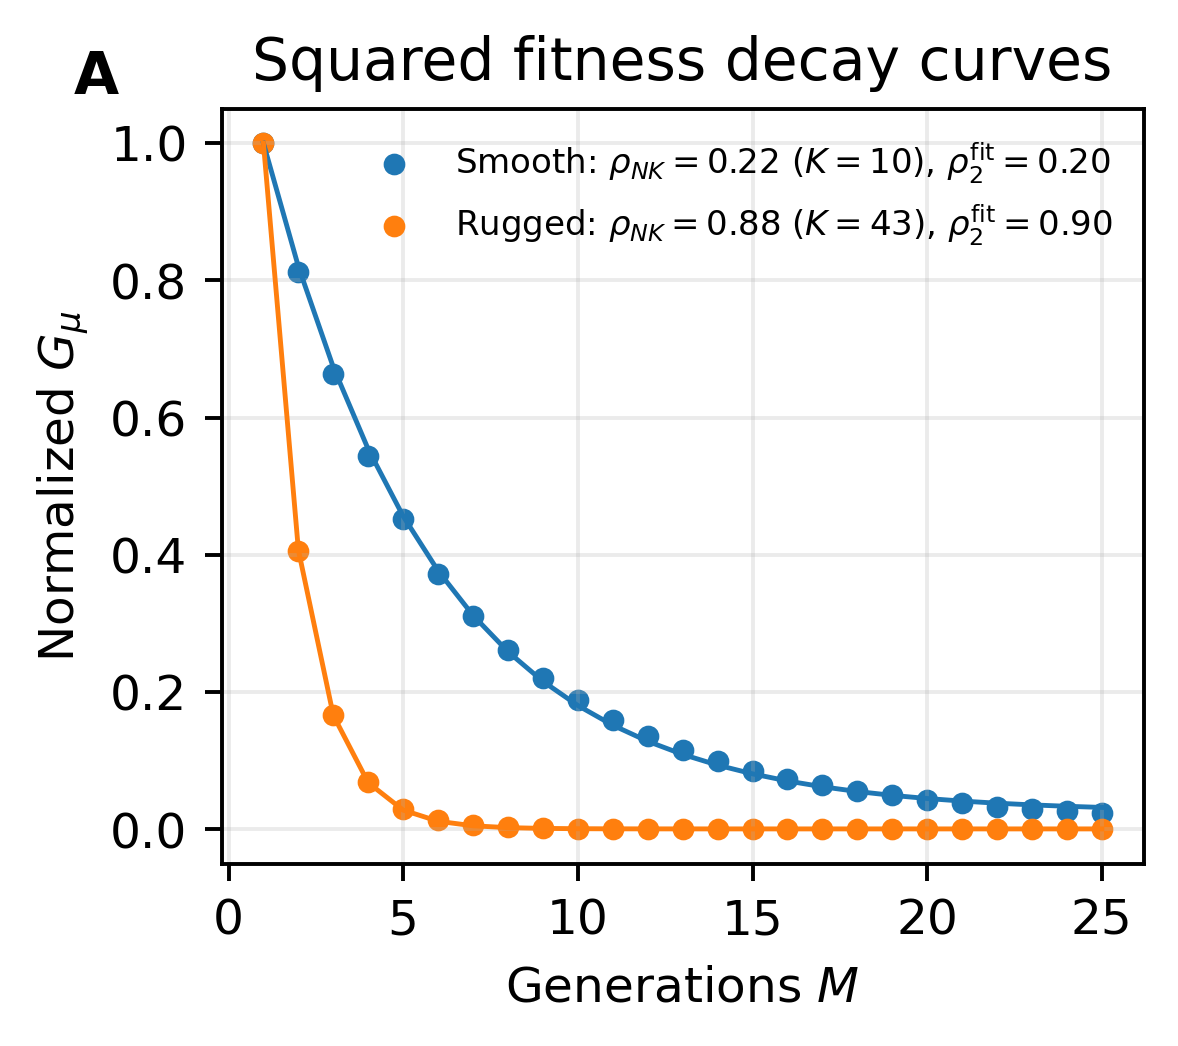

In [4]:
PANEL_A_NK_EXAMPLES: dict[str, tuple[int, int]] = {
    "smooth": (50, 10),
    "rugged": (50, 43),
}
PANEL_A_LANDSCAPE_INDEX = 0

savepath_decay_examples_payload = PROCESSED_DATA_DIR / PROCESSED_FILES["decay_examples"]
if savepath_decay_examples_payload.exists() and not OVERWRITE_PKL:
    print(f"{savepath_decay_examples_payload} already exists. Loading existing processed payload.")
    decay_examples_payload = load_pickle(savepath_decay_examples_payload)
    decay_examples = decay_examples_payload["data"]
else:
    pair_to_index = {(int(N), int(K)): index for index, (N, K) in enumerate(nk_pairs)}
    decay_examples = {
        "smooth_rugged": [],
        "fitted_lines": [],
        "labels": [],
        "examples": {},
        "generations": np.arange(1, int(nk_decay_params["M"]) + 1),
    }

    for name, pair in PANEL_A_NK_EXAMPLES.items():
        if pair not in pair_to_index:
            raise ValueError(f"Requested Panel A pair {pair} is absent from nk_pairs: {nk_pairs.tolist()}")
        grid_index = pair_to_index[pair]
        N, K = pair
        rho_nk = (K + 1) / N
        start_curves = nk_decay_grid[grid_index, PANEL_A_LANDSCAPE_INDEX]
        g_mu = start_curves_to_gmu(start_curves, average_axis=0)
        normalized_g_mu = normalize_curve(g_mu)
        fitted_curve, rho_2_fit = fitted_gmu_curve(g_mu, mutation_rate=float(nk_decay_params["mutation_rate"]))
        label = rf"{name.title()}: $\rho_{{NK}}={rho_nk:.2f}$ ($K={K}$), $\rho_2^{{\mathrm{{fit}}}}={rho_2_fit:.2f}$"

        decay_examples["smooth_rugged"].append(normalized_g_mu)
        decay_examples["fitted_lines"].append(fitted_curve)
        decay_examples["labels"].append(label)
        decay_examples["examples"][name] = {
            "N": int(N),
            "K": int(K),
            "rho_NK": float(rho_nk),
            "rho_2_fit": float(rho_2_fit),
            "grid_index": int(grid_index),
            "landscape_index": int(PANEL_A_LANDSCAPE_INDEX),
            "num_starts": int(nk_decay_params["num_starts"]),
            "num_reps_per_start": int(nk_decay_params["num_reps_per_start"]),
            "legend_label": label,
        }

    decay_examples_payload = {
        "data": decay_examples,
        "params": {**nk_decay_params, "panel_a_examples": decay_examples["examples"]},
        "metadata": {
            "description": "Processed NK G_mu example decay curves for Figure 3 new Panel A.",
            "paper_reference": "Figure 3A",
            "output_key": "figure3_new_decay_examples",
            "filename": PROCESSED_FILES["decay_examples"],
        },
    }
    save_pickle(decay_examples_payload, savepath_decay_examples_payload)

print("Figure 3 new Panel A selected NK examples:")
for name, info in decay_examples["examples"].items():
    print(
        f"  {name}: grid_index={info['grid_index']}, landscape={info['landscape_index']}, "
        f"N={info['N']}, K={info['K']}, rho_NK={info['rho_NK']:.3f}, "
        f"rho_2_fit={info['rho_2_fit']:.3f}"
    )

fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=PANEL_DPI)
for curve, fitted_line, label, colour in zip(
    decay_examples["smooth_rugged"],
    decay_examples["fitted_lines"],
    decay_examples["labels"],
    ["tab:blue", "tab:orange"],
):
    ax.scatter(decay_examples["generations"], curve, label=label, color=colour, s=12)
    ax.plot(decay_examples["generations"], fitted_line, color=colour, linewidth=1)
ax.set_title(r"Squared fitness decay curves")
ax.set_xlabel(r"Generations $M$")
ax.set_ylabel(r"Normalized $G_\mu$")
ax.legend(frameon=False, fontsize=7)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "A")
save_panel_figure(fig, "figure_3_new_A")
plt.show()


### Panel B - G_mu Ruggedness Accuracy

For each NK landscape, average $F_\mu$ over replicate runs per start, square those start-level curves, and average over starts to obtain one $G_\mu$ curve per landscape. The panel reports fitted $\rho_2$ values across landscapes for each analytical $\rho_{NK}$.


/home/idris/workspace_python/SLIDE/processed_data/figure3_new_ruggedness_accuracy_processed.pkl already exists. Loading existing raw payload.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


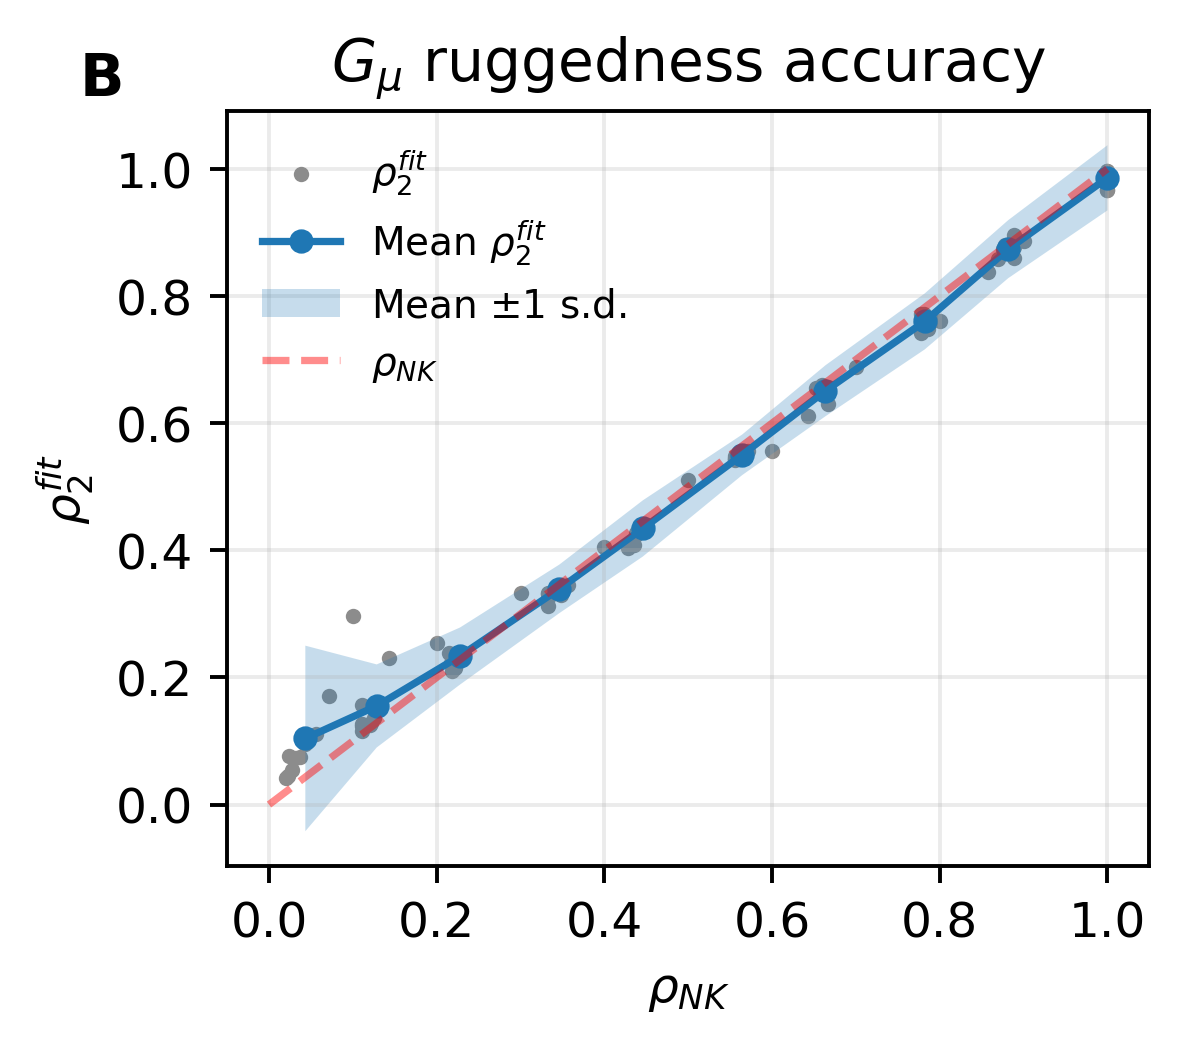

In [5]:
steps = int(nk_decay_params["M"])
mutation_rate = float(nk_decay_params["mutation_rate"])
rho_NK_all = (nk_pairs[:, 1] + 1) / nk_pairs[:, 0]
if np.any(rho_NK_all > 1):
    raise ValueError("Calculated rho_NK values must be in the range [0, 1]. Check NK pairs.")

savepath_ruggedness_accuracy_payload = Path(PROCESSED_DATA_DIR / PROCESSED_FILES["ruggedness_accuracy"])
if savepath_ruggedness_accuracy_payload.exists() and not OVERWRITE_PKL:
    print(f"{savepath_ruggedness_accuracy_payload} already exists. Loading existing raw payload.")
    ruggedness_accuracy_payload = load_pickle(savepath_ruggedness_accuracy_payload)
    ruggedness_accuracy_processed = ruggedness_accuracy_payload["data"]
else:
    rho_2_fit_by_pair = np.zeros((nk_decay_grid.shape[0], nk_decay_grid.shape[1]), dtype=float)
    for pair_index in range(nk_decay_grid.shape[0]):
        for landscape_index in range(nk_decay_grid.shape[1]):
            g_mu = start_curves_to_gmu(nk_decay_grid[pair_index, landscape_index], average_axis=0)
            rho_2_fit_by_pair[pair_index, landscape_index] = fit_gmu_decay(
                g_mu,
                mutation_rate=mutation_rate,
                num_steps=steps,
            )[0]

    order = np.argsort(rho_NK_all)
    rho_2_fit_mean_by_pair = rho_2_fit_by_pair.mean(axis=1)
    rho_2_fit_std_by_pair = rho_2_fit_by_pair.std(axis=1)

    PANEL_B_NUM_BINS = 10
    rho_NK_repeated = np.repeat(rho_NK_all, rho_2_fit_by_pair.shape[1])
    rho_2_fit_flat = rho_2_fit_by_pair.reshape(-1)
    bin_edges = np.linspace(0, 1, PANEL_B_NUM_BINS + 1)
    bin_indices = np.clip(np.digitize(rho_NK_repeated, bin_edges, right=True) - 1, 0, PANEL_B_NUM_BINS - 1)

    binned_rho_NK = []
    binned_rho_2_fit_mean = []
    binned_rho_2_fit_std = []
    binned_counts = []
    for bin_index in range(PANEL_B_NUM_BINS):
        in_bin = bin_indices == bin_index
        if not np.any(in_bin):
            continue
        binned_rho_NK.append(rho_NK_repeated[in_bin].mean())
        binned_rho_2_fit_mean.append(rho_2_fit_flat[in_bin].mean())
        binned_rho_2_fit_std.append(rho_2_fit_flat[in_bin].std())
        binned_counts.append(int(in_bin.sum()))

    binned_rho_NK = np.asarray(binned_rho_NK, dtype=float)
    binned_rho_2_fit_mean = np.asarray(binned_rho_2_fit_mean, dtype=float)
    binned_rho_2_fit_std = np.asarray(binned_rho_2_fit_std, dtype=float)
    binned_counts = np.asarray(binned_counts, dtype=int)

    ruggedness_accuracy_processed = {
        "rho_NK": rho_NK_all[order],
        "rho_2_fit_mean": rho_2_fit_mean_by_pair[order],
        "rho_2_fit_std": rho_2_fit_std_by_pair[order],
        "rho_2_fit_all": rho_2_fit_by_pair,
        "rho_NK_all": rho_NK_all,
        "binned_rho_NK": binned_rho_NK,
        "binned_rho_2_fit_mean": binned_rho_2_fit_mean,
        "binned_rho_2_fit_std": binned_rho_2_fit_std,
        "binned_counts": binned_counts,
        "bin_edges": bin_edges,
    }

    ruggedness_accuracy_payload = {
        "data": ruggedness_accuracy_processed,
        "params": nk_decay_params,
        "metadata": {
            "description": "Processed NK G_mu ruggedness prediction accuracy for Figure 3 new Panel B.",
            "paper_reference": "Figure 3B",
            "output_key": "figure3_new_ruggedness_accuracy",
            "filename": PROCESSED_FILES["ruggedness_accuracy"],
        },
    }
    save_pickle(ruggedness_accuracy_payload, savepath_ruggedness_accuracy_payload)

panel_data = ruggedness_accuracy_processed
fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=PANEL_DPI)
ax.scatter(
    panel_data["rho_NK"],
    panel_data["rho_2_fit_mean"],
    s=10,
    color="0.55",
    alpha=1,
    linewidths=0,
    label=r"$\rho_2^{fit}$",
)
ax.plot(
    panel_data["binned_rho_NK"],
    panel_data["binned_rho_2_fit_mean"],
    "o-",
    markersize=4,
    label=r"Mean $\rho_2^{fit}$",
)
ax.fill_between(
    panel_data["binned_rho_NK"],
    panel_data["binned_rho_2_fit_mean"] - panel_data["binned_rho_2_fit_std"],
    panel_data["binned_rho_2_fit_mean"] + panel_data["binned_rho_2_fit_std"],
    alpha=0.25,
    label=r"Mean $\pm$1 s.d.",
)
ax.plot([0, 1], [0, 1], color="red", alpha=0.45, linestyle="--", label=r"$\rho_{NK}$")
ax.set_title(r"$G_\mu$ ruggedness accuracy")
ax.set_xlabel(r"$\rho_{NK}$")
ax.set_ylabel(r"$\rho_2^{fit}$")
ax.legend(frameon=False, fontsize=8)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "B")
save_panel_figure(fig, "figure_3_new_B")
plt.show()


### F_mu Starting-Fitness Subpanels

Add standalone F_mu versions of Panels A and B. The example decay panel contrasts a start close to the sampled landscape-average fitness with a high-fitness start, while the accuracy panel compares binned rho_1 fits from all starts and high-fitness starts.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


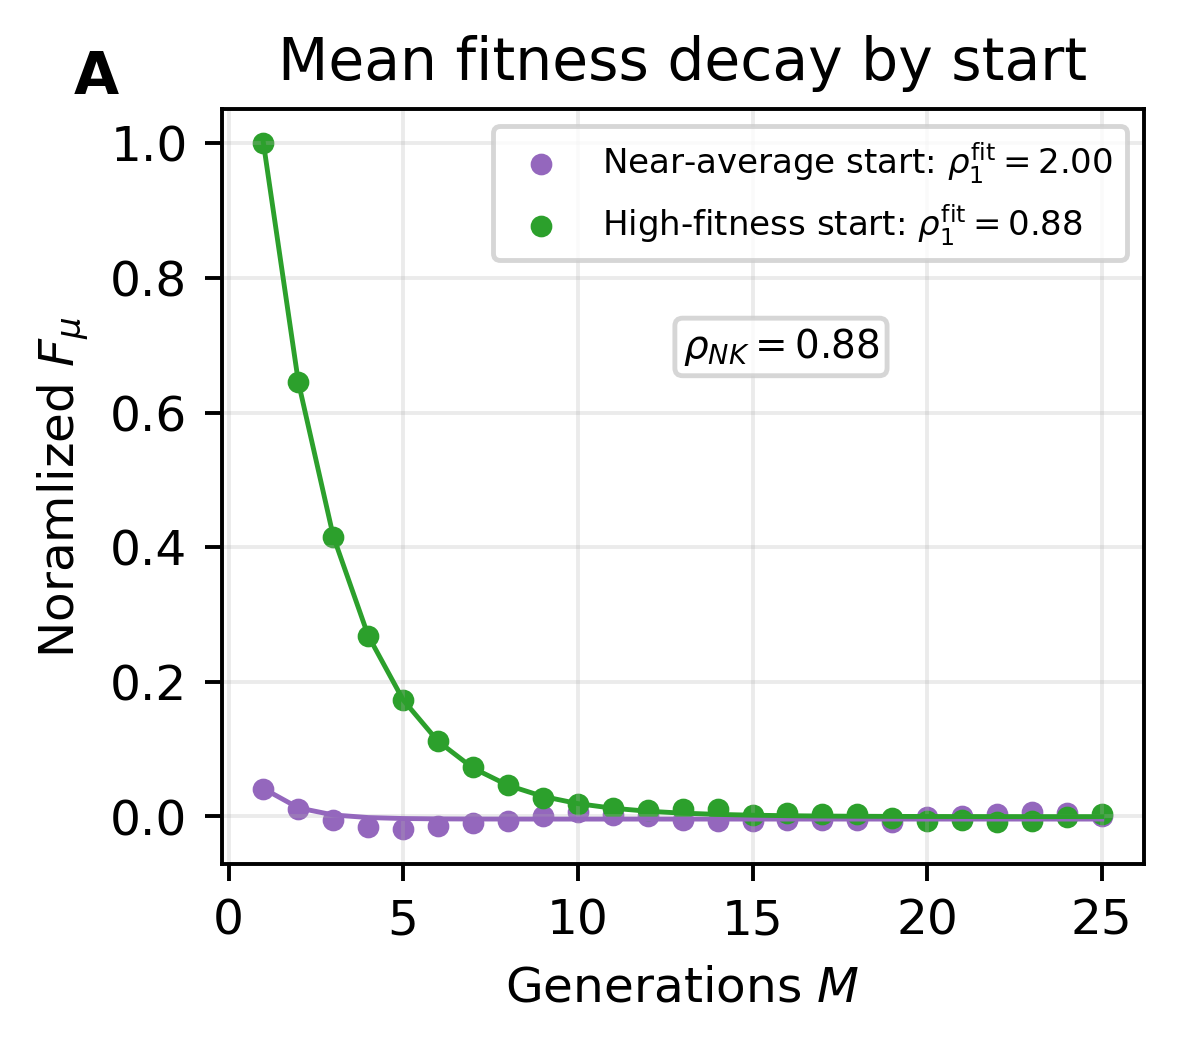

In [6]:
PANEL_A_FMU_PAIR = PANEL_A_NK_EXAMPLES["rugged"]
PANEL_A_FMU_LANDSCAPE_INDEX = 0
PANEL_A_AVERAGE_START_QUANTILE = 0.25
PANEL_B_HIGH_FITNESS_QUANTILE = 0.8
PANEL_B_FMU_NUM_BINS = 10

pair_to_index = {(int(N), int(K)): index for index, (N, K) in enumerate(nk_pairs)}
if PANEL_A_FMU_PAIR not in pair_to_index:
    raise ValueError(f"Requested F_mu Panel A pair {PANEL_A_FMU_PAIR} is absent from nk_pairs: {nk_pairs.tolist()}")

fmu_pair_index = pair_to_index[PANEL_A_FMU_PAIR]
fmu_start_curves = nk_decay_grid[fmu_pair_index, PANEL_A_FMU_LANDSCAPE_INDEX]
fmu_initial_fitness = fmu_start_curves[:, 0]
fmu_generations = np.arange(1, steps + 1)
N, K = PANEL_A_FMU_PAIR
rho_nk = (K + 1) / N
rho_1_fit_by_start = np.asarray([
    get_single_decay_rate(normalize_curve(curve), mut=mutation_rate, num_steps=steps)[0]
    for curve in fmu_start_curves
])
rho_1_constant_by_start = np.asarray([
    get_single_decay_rate(normalize_curve(curve), mut=mutation_rate, num_steps=steps)[1]
    for curve in fmu_start_curves
])

average_distances = np.abs(fmu_initial_fitness - fmu_initial_fitness.mean())
average_start_threshold = np.quantile(average_distances, PANEL_A_AVERAGE_START_QUANTILE)
average_start_candidates = np.flatnonzero(average_distances <= average_start_threshold)
high_start_threshold = np.quantile(fmu_initial_fitness, PANEL_B_HIGH_FITNESS_QUANTILE)
high_start_candidates = np.flatnonzero(fmu_initial_fitness >= high_start_threshold)
if len(average_start_candidates) == 0 or len(high_start_candidates) == 0:
    raise ValueError("Could not find both average-fitness and high-fitness F_mu starts.")

landscape_average_start_index = int(
    average_start_candidates[np.argmax(np.abs(rho_1_fit_by_start[average_start_candidates] - rho_nk))]
)
high_fitness_start_index = int(
    high_start_candidates[np.argmin(np.abs(rho_1_fit_by_start[high_start_candidates] - rho_nk))]
)

fmu_examples = {
    "average_start": fmu_start_curves[landscape_average_start_index],
    "high_start": fmu_start_curves[high_fitness_start_index],
}
fmu_example_fits = {
    "average_start": (rho_1_fit_by_start[landscape_average_start_index], rho_1_constant_by_start[landscape_average_start_index]),
    "high_start": (rho_1_fit_by_start[high_fitness_start_index], rho_1_constant_by_start[high_fitness_start_index]),
}

high_fitness_normalizer = fmu_examples["high_start"][0]
fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=PANEL_DPI)
for name, curve, colour, label_prefix in [
    ("average_start", fmu_examples["average_start"], "tab:purple", "Near-average start"),
    ("high_start", fmu_examples["high_start"], "tab:green", "High-fitness start"),
]:
    normalized_curve = curve / high_fitness_normalizer
    rho_1_fit, fitted_constant = fmu_example_fits[name]
    ax.scatter(
        fmu_generations,
        normalized_curve,
        color=colour,
        s=12,
        label=rf"{label_prefix}: $\rho_1^{{\mathrm{{fit}}}}={rho_1_fit:.2f}$",
    )
    ax.plot(
        fmu_generations,
        model_function(np.arange(steps), rho_1_fit, fitted_constant, mut=mutation_rate) * curve[0] / high_fitness_normalizer,
        color=colour,
        linewidth=1,
    )
ax.set_title(r"Mean fitness decay by start")
ax.set_xlabel(r"Generations $M$")
ax.set_ylabel(r"Noramlized $F_\mu$")
ax.text(0.5, 0.67, rf"$\rho_{{NK}}={rho_nk:.2f}$", transform=ax.transAxes, fontsize=8,
        bbox=dict(
    boxstyle="round,pad=0.2",
    facecolor="white",
    edgecolor="0.8",
    alpha=0.8,
))
ax.legend(frameon=True, fontsize=7)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "A")
save_panel_figure(fig, "figure_3_new_A_fmu")
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


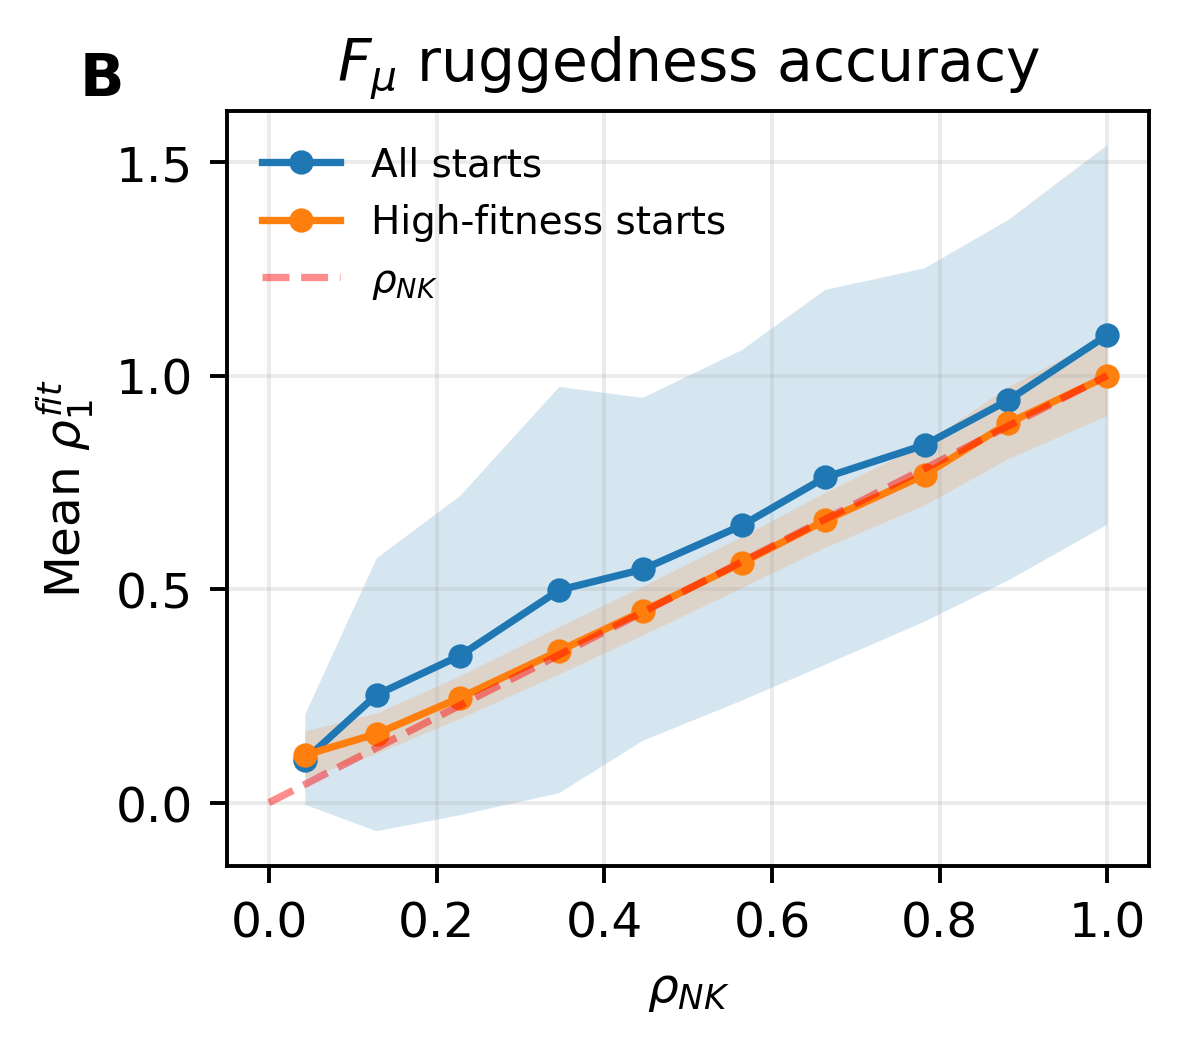

In [7]:

rho_1_fit_all_starts = np.zeros((nk_decay_grid.shape[0], nk_decay_grid.shape[1]), dtype=float)
rho_1_fit_high_starts = np.zeros_like(rho_1_fit_all_starts)
for pair_index in range(nk_decay_grid.shape[0]):
    for landscape_index in range(nk_decay_grid.shape[1]):
        start_curves = nk_decay_grid[pair_index, landscape_index]
        start_initial_fitness = start_curves[:, 0]
        high_threshold = np.quantile(start_initial_fitness, PANEL_B_HIGH_FITNESS_QUANTILE)
        high_start_curves = start_curves[start_initial_fitness >= high_threshold]
        all_f_mu = start_curves.mean(axis=0)
        high_f_mu = high_start_curves.mean(axis=0)
        rho_1_fit_all_starts[pair_index, landscape_index] = get_single_decay_rate(
            normalize_curve(all_f_mu),
            mut=mutation_rate,
            num_steps=steps,
        )[0]
        rho_1_fit_high_starts[pair_index, landscape_index] = get_single_decay_rate(
            normalize_curve(high_f_mu),
            mut=mutation_rate,
            num_steps=steps,
        )[0]

rho_NK_repeated = np.repeat(rho_NK_all, rho_1_fit_all_starts.shape[1])
rho_1_fit_all_flat = rho_1_fit_all_starts.reshape(-1)
rho_1_fit_high_flat = rho_1_fit_high_starts.reshape(-1)
fmu_bin_edges = np.linspace(0, 1, PANEL_B_FMU_NUM_BINS + 1)
fmu_bin_indices = np.clip(np.digitize(rho_NK_repeated, fmu_bin_edges, right=True) - 1, 0, PANEL_B_FMU_NUM_BINS - 1)

binned_fmu_rho_NK = []
binned_rho_1_all_mean = []
binned_rho_1_all_std = []
binned_rho_1_high_mean = []
binned_rho_1_high_std = []
for bin_index in range(PANEL_B_FMU_NUM_BINS):
    in_bin = fmu_bin_indices == bin_index
    if not np.any(in_bin):
        continue
    binned_fmu_rho_NK.append(rho_NK_repeated[in_bin].mean())
    binned_rho_1_all_mean.append(rho_1_fit_all_flat[in_bin].mean())
    binned_rho_1_all_std.append(rho_1_fit_all_flat[in_bin].std())
    binned_rho_1_high_mean.append(rho_1_fit_high_flat[in_bin].mean())
    binned_rho_1_high_std.append(rho_1_fit_high_flat[in_bin].std())

binned_fmu_rho_NK = np.asarray(binned_fmu_rho_NK, dtype=float)
binned_rho_1_all_mean = np.asarray(binned_rho_1_all_mean, dtype=float)
binned_rho_1_all_std = np.asarray(binned_rho_1_all_std, dtype=float)
binned_rho_1_high_mean = np.asarray(binned_rho_1_high_mean, dtype=float)
binned_rho_1_high_std = np.asarray(binned_rho_1_high_std, dtype=float)

fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=PANEL_DPI)
ax.plot(binned_fmu_rho_NK, binned_rho_1_all_mean, "o-", markersize=4, label="All starts")
ax.fill_between(
    binned_fmu_rho_NK,
    binned_rho_1_all_mean - binned_rho_1_all_std,
    binned_rho_1_all_mean + binned_rho_1_all_std,
    alpha=0.18,
)
ax.plot(binned_fmu_rho_NK, binned_rho_1_high_mean, "o-", markersize=4, label="High-fitness starts")
ax.fill_between(
    binned_fmu_rho_NK,
    binned_rho_1_high_mean - binned_rho_1_high_std,
    binned_rho_1_high_mean + binned_rho_1_high_std,
    alpha=0.18,
)
ax.plot([0, 1], [0, 1], color="red", alpha=0.45, linestyle="--", label=r"$\rho_{NK}$")
ax.set_title(r"$F_\mu$ ruggedness accuracy")
ax.set_xlabel(r"$\rho_{NK}$")
ax.set_ylabel(r"Mean $\rho_1^{fit}$")
ax.legend(frameon=False, fontsize=8)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "B")
save_panel_figure(fig, "figure_3_new_B_fmu")
plt.show()


In [ ]:
METRIC_N_SITES = 12
METRIC_NUM_ALLELES = 2
METRIC_K_VALUES = np.arange(METRIC_N_SITES, dtype=int)
METRIC_NUM_LANDSCAPES = 50
METRIC_SEED = 42
metric_shape = (METRIC_NUM_ALLELES,) * METRIC_N_SITES
metric_rng_keys = jr.split(jr.PRNGKey(METRIC_SEED), METRIC_NUM_LANDSCAPES)
metric_start = np.zeros(METRIC_N_SITES, dtype=int)
metric_rho_NK = (METRIC_K_VALUES + 1) / METRIC_N_SITES

savepath_metric_comparison_payload = Path(PROCESSED_DATA_DIR / PROCESSED_FILES["metric_comparison"])
if savepath_metric_comparison_payload.exists() and not OVERWRITE_PKL:
    print(f"{savepath_metric_comparison_payload} already exists. Loading existing raw payload.")
    metric_comparison_payload = load_pickle(savepath_metric_comparison_payload)
    metric_comparison_processed = metric_comparison_payload["data"]
else:
    metric_roughness_to_slope = np.zeros((len(METRIC_K_VALUES), METRIC_NUM_LANDSCAPES), dtype=float)
    metric_fourier_r2 = np.zeros_like(metric_roughness_to_slope)
    metric_paths_to_max = np.zeros_like(metric_roughness_to_slope)
    metric_closest_max = np.zeros_like(metric_roughness_to_slope)
    metric_local_epistasis = np.zeros_like(metric_roughness_to_slope)
    metric_rho_2_dirichlet = np.zeros_like(metric_roughness_to_slope)
    metric_spectral_entropy = np.zeros_like(metric_roughness_to_slope)

    for k_index, K in enumerate(tqdm(METRIC_K_VALUES, desc="Analytical NK metrics")):
        metric_landscapes = jnp.stack([
            get_nk_l_o_shape(
                metric_rng_key,
                METRIC_N_SITES,
                int(K),
                metric_shape,
            )
            for metric_rng_key in metric_rng_keys
        ])
        epistasis_counts = jax.vmap(lambda landscape: local_epistasis(landscape, metric_start))(metric_landscapes)

        metric_roughness_to_slope[k_index] = np.asarray(jax.vmap(roughness_to_slope)(metric_landscapes), dtype=float)
        metric_fourier_r2[k_index] = np.asarray(jax.vmap(landscape_r2)(metric_landscapes), dtype=float)
        metric_paths_to_max[k_index] = np.asarray(
            [
                get_mean_paths_to_max(landscape, norm=False, extra_slack=0)
                for landscape in metric_landscapes
            ],
            dtype=float,
        )
        metric_closest_max[k_index] = np.asarray(
            1 / jax.vmap(find_distance_to_closest_max)(metric_landscapes),
            dtype=float,
        )
        metric_local_epistasis[k_index] = np.asarray(
            epistasis_counts["simple_sign_episasis"] + epistasis_counts["reciprocal_sign_epistasis"],
            dtype=float,
        )
        metric_rho_2_dirichlet[k_index] = np.asarray(
            jax.vmap(get_dirichlet_metric)(metric_landscapes),
            dtype=float,
        )
        metric_spectral_entropy[k_index] = np.asarray(
            jax.vmap(get_spectral_entropy)(metric_landscapes),
            dtype=float,
        )

    rho_2_fit_by_pair = ruggedness_accuracy_processed["rho_2_fit_all"]
    panel_b_rho_values = np.repeat(rho_NK_all, rho_2_fit_by_pair.shape[1])
    panel_b_rho_2_values = rho_2_fit_by_pair.reshape(-1)
    metric_bin_edges = np.concatenate(
        [
            [-np.inf],
            (metric_rho_NK[:-1] + metric_rho_NK[1:]) / 2,
            [np.inf],
        ]
    )
    metric_rho_2_fit_mean = np.zeros_like(metric_rho_NK, dtype=float)
    metric_rho_2_fit_std = np.zeros_like(metric_rho_NK, dtype=float)
    metric_rho_2_fit_counts = np.zeros_like(metric_rho_NK, dtype=int)

    for metric_index in range(len(metric_rho_NK)):
        in_bin = (
            (panel_b_rho_values > metric_bin_edges[metric_index])
            & (panel_b_rho_values <= metric_bin_edges[metric_index + 1])
        )
        metric_rho_2_fit_mean[metric_index] = panel_b_rho_2_values[in_bin].mean()
        metric_rho_2_fit_std[metric_index] = panel_b_rho_2_values[in_bin].std()
        metric_rho_2_fit_counts[metric_index] = int(in_bin.sum())

    metric_comparison_processed = {
        "rho_NK": metric_rho_NK,
        "rho_2_fit_mean": metric_rho_2_fit_mean,
        "rho_2_fit_std": metric_rho_2_fit_std,
        "rho_2_fit_counts": metric_rho_2_fit_counts,
        "rho_2_dirichlet": metric_rho_2_dirichlet.mean(axis=1),
        "spectral_entropy": metric_spectral_entropy.mean(axis=1),
        "roughness_to_slope": metric_roughness_to_slope.mean(axis=1),
        "fourier_r2": metric_fourier_r2.mean(axis=1),
        "paths_to_max": metric_paths_to_max.mean(axis=1),
        "closest_max": metric_closest_max.mean(axis=1),
        "local_epistasis": metric_local_epistasis.mean(axis=1),
    }
    metric_comparison_payload = {
        "params": {
            "N": METRIC_N_SITES,
            "A": METRIC_NUM_ALLELES,
            "K_values": METRIC_K_VALUES,
            "num_landscapes": METRIC_NUM_LANDSCAPES,
            "seed": METRIC_SEED,
        },
        "data": metric_comparison_processed,
    }
    save_pickle(metric_comparison_payload, savepath_metric_comparison_payload)

metric_comparison_processed


{'rho_NK': array([0.08333333, 0.16666667, 0.25      , 0.33333333, 0.41666667,
        0.5       , 0.58333333, 0.66666667, 0.75      , 0.83333333,
        0.91666667, 1.        ]),
 'rho_2_fit_mean': array([0.1149427 , 0.21261371, 0.22269757, 0.3321331 , 0.423899  ,
        0.50998681, 0.55007636, 0.65092292, 0.75991251, 0.83288944,
        0.88077179, 0.98592794]),
 'rho_2_fit_std': array([0.11350167, 0.0921178 , 0.02473981, 0.03214147, 0.03198591,
        0.07962747, 0.03191274, 0.04008911, 0.04058759, 0.06711244,
        0.04308859, 0.05127503]),
 'rho_2_fit_counts': array([425,  75, 225, 250, 250,  25, 250, 250, 225, 100, 175, 250]),
 'rho_2_dirichlet': array([0.16666667, 0.22031957, 0.29021188, 0.35768653, 0.43324388,
        0.51055429, 0.5916498 , 0.67198855, 0.75033061, 0.83491627,
        0.91739843, 1.00185018]),
 'spectral_entropy': array([1.65418168e-13, 2.36925313e-01, 3.93850592e-01, 4.89120156e-01,
        5.63241973e-01, 6.18297535e-01, 6.62770441e-01, 6.99034926e-01,
  

### Panel F - Metric Comparison

Use the $G_\mu$-based fitted $\rho_2$ values from Panel B as the decay-rate metric in the normalized comparison against other ruggedness summaries.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


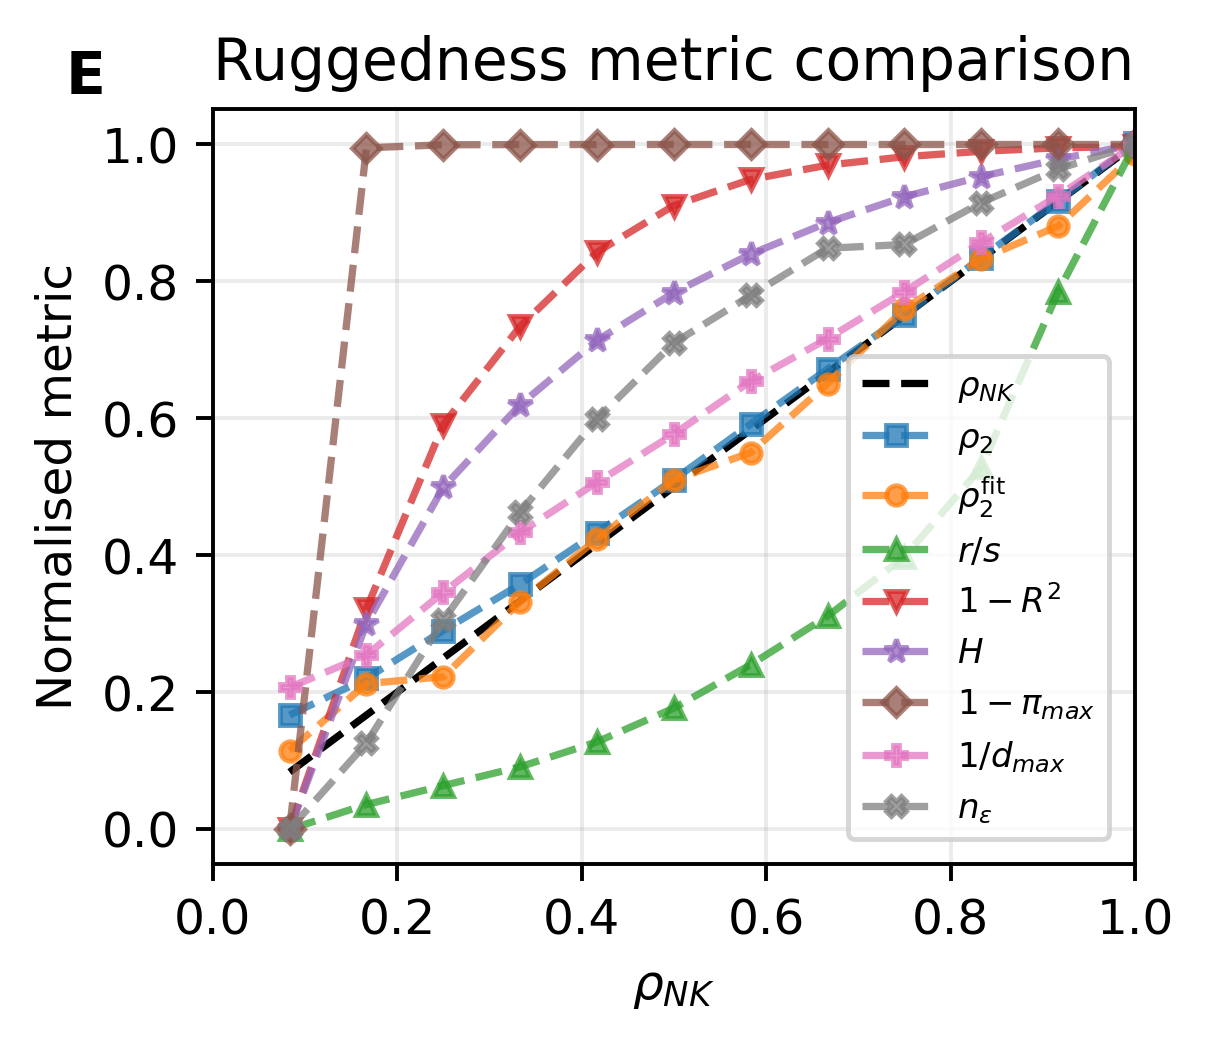

In [ ]:
panel_data = metric_comparison_processed
# label_data = {
#     "roughness_to_slope": "Roughness-to-slope ratio",
#     "fourier_r2": r"1 - Landscape $R^2$",
#     "paths_to_max": "1 - Paths to maximum",
#     "closest_max": "Inverse distance to closest local maximum",
#     "local_epistasis": "Local epistasis",
# }
label_data = {
    "roughness_to_slope": r"$r/s$",
    "fourier_r2": r"$1 - R^2$",
    "paths_to_max": r"$1 - \pi_{max}$",
    "closest_max": r"$1/d_{max}$",
    "local_epistasis": r"$n_{\epsilon}$",
    "spectral_entropy": r"$H$",
}
marker_data = {
    "roughness_to_slope": "^",
    "fourier_r2": "v",
    "paths_to_max": "D",
    "closest_max": "P",
    "local_epistasis": "X",
    "spectral_entropy": "*",
}
fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=PANEL_DPI)
rho_axis = np.asarray(panel_data["rho_NK"], dtype=float)
rho_2_fit = np.asarray(panel_data["rho_2_fit_mean"], dtype=float)
rho_2_dirichlet = np.asarray(panel_data["rho_2_dirichlet"], dtype=float)



ax.plot(rho_axis, rho_axis, color="black", alpha=1, linestyle="--", label=r"$\rho_{NK}$")
ax.plot(rho_axis, rho_2_dirichlet, "s--", alpha=0.75, markersize=4, label=r"$\rho_2$")
ax.plot(rho_axis, rho_2_fit, "o--", alpha=0.75, markersize=4, label=r"$\rho_2^{{\mathrm{fit}}}$")
ax.plot(
    rho_axis,
    panel_data["roughness_to_slope"] / panel_data["roughness_to_slope"].max(),
    label=label_data["roughness_to_slope"],
    alpha=0.75,
    linestyle="--",
    marker=marker_data["roughness_to_slope"],
    markersize=4,
)
ax.plot(
    rho_axis,
    1 - panel_data["fourier_r2"] / panel_data["fourier_r2"].max(),
    label=label_data["fourier_r2"],
    alpha=0.75,
    linestyle="--",
    marker=marker_data["fourier_r2"],
    markersize=4,
)
ax.plot(
    rho_axis,
    panel_data["spectral_entropy"] / panel_data["spectral_entropy"].max(),
    label=label_data["spectral_entropy"],
    alpha=0.75,
    linestyle="--",
    marker=marker_data["spectral_entropy"],
    markersize=5,
)
ax.plot(
    rho_axis,
    1 - panel_data["paths_to_max"] / panel_data["paths_to_max"].max(),
    label=label_data["paths_to_max"],
    alpha=0.75,
    linestyle="--",
    marker=marker_data["paths_to_max"],
    markersize=4,
)
ax.plot(
    rho_axis,
    panel_data["closest_max"] / panel_data["closest_max"].max(),
    label=label_data["closest_max"],
    alpha=0.75,
    linestyle="--",
    marker=marker_data["closest_max"],
    markersize=4,
)
ax.plot(
    rho_axis,
    panel_data["local_epistasis"] / panel_data["local_epistasis"].max(),
    label=label_data["local_epistasis"],
    alpha=0.75,
    linestyle="--",
    marker=marker_data["local_epistasis"],
    markersize=4,
)
ax.set_title("Ruggedness metric comparison")
ax.set_xlim(0, 1)
ax.set_xlabel(r"$\rho_{NK}$")
ax.set_ylabel("Normalised metrics")
ax.legend(loc="lower right", bbox_to_anchor=(0.99, 0.01), fontsize=7, frameon=True, ncol=1)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "F")
save_panel_figure(fig, "figure_3_new_F")
plt.show()


## Starting-Point Accuracy Sweep - Panel C

Generate the starting-point sensitivity data with start-resolved $F_\mu$ curves. The processed panel converts each landscape to $G_\mu$ by squaring start-level curves before averaging starts.


In [ ]:
start_count_params = {
    "N": 25,
    "K": 15,
    "A": 2,
    "num_landscapes": 25,
    "num_reps_per_start": 5,
    "M": 25,
    "seed": 42,
    "start_policy": "random",
    "popsize": 2000,
    "num_starts": np.unique(np.round(np.logspace(0, 3, num=10)).astype(int)),
    "mutation_rate": 0.5,
}
start_count_params["rho_NK"] = (start_count_params["K"] + 1) / start_count_params["N"]

start_count_accuracy_path = RAW_DATA_DIR / RAW_FILES["nk_start_count_accuracy"]
print_params("Figure 3 new NK starting-point G_mu parameters", start_count_params, start_count_accuracy_path)

if start_count_accuracy_path.exists() and not OVERWRITE_PKL:
    print(f"{start_count_accuracy_path} already exists. Loading existing raw payload.")
    start_count_accuracy_payload = load_pickle(start_count_accuracy_path)
else:
    start_count_key = jr.PRNGKey(start_count_params["seed"])
    landscape_keys = jr.split(start_count_key, start_count_params["num_landscapes"])
    start_count_accuracy = []

    for num_starts in tqdm(start_count_params["num_starts"], desc="Figure 3 new starting-point G_mu"):
        start_count_results = []
        for landscape_index, landscape_key in enumerate(landscape_keys):
            start_keys = jr.split(jr.fold_in(landscape_key, 100_000 + landscape_index), int(num_starts))
            starts = np.asarray([
                random_start(start_key, n_sites=start_count_params["N"], num_alleles=start_count_params["A"])
                for start_key in start_keys
            ])
            start_curves = run_nk_start_averaged_diffusion(
                rng_key=landscape_key,
                n_sites=start_count_params["N"],
                k=start_count_params["K"],
                num_alleles=start_count_params["A"],
                starts=starts,
                popsize=start_count_params["popsize"],
                mutation_rate_per_site=start_count_params["mutation_rate"] / start_count_params["N"],
                num_reps_per_start=start_count_params["num_reps_per_start"],
                num_steps=start_count_params["M"],
            )
            start_count_results.append(np.asarray(start_curves, dtype=float))
        start_count_accuracy.append(start_count_results)

    start_count_accuracy_raw = np.empty(
        (len(start_count_params["num_starts"]), start_count_params["num_landscapes"]),
        dtype=object,
    )
    for start_count_index, start_count_results in enumerate(start_count_accuracy):
        for landscape_index, start_curves in enumerate(start_count_results):
            start_count_accuracy_raw[start_count_index, landscape_index] = start_curves

    start_count_accuracy_payload = {
        "data": start_count_accuracy_raw,
        "params": start_count_params,
        "metadata": {
            "description": "Start-resolved NK starting-point sensitivity sweep for Figure 3 new Panel C.",
            "paper_reference": "Figure 3C",
            "output_key": "figure3_new_nk_start_count_accuracy",
            "filename": RAW_FILES["nk_start_count_accuracy"],
            "shape": "start_count, landscape, start, generation",
        },
    }
    save_pickle(start_count_accuracy_payload, start_count_accuracy_path)

start_count_accuracy_processed_path = PROCESSED_DATA_DIR / PROCESSED_FILES["start_count_accuracy"]
if start_count_accuracy_processed_path.exists() and not OVERWRITE_PKL:
    print(f"{start_count_accuracy_processed_path} already exists. Loading existing processed payload.")
    start_count_accuracy_processed_payload = load_pickle(start_count_accuracy_processed_path)
    start_count_processed = start_count_accuracy_processed_payload["data"]
    start_count_params = start_count_accuracy_processed_payload["params"]
    start_count_rates = np.asarray(start_count_processed["rates"], dtype=float)
else:
    start_count_accuracy_raw = np.asarray(start_count_accuracy_payload["data"], dtype=object)
    start_count_params = start_count_accuracy_payload["params"]
    print(f"Loaded start-count accuracy shape: {start_count_accuracy_raw.shape}")

    start_count_rates = np.zeros(start_count_accuracy_raw.shape[:2], dtype=float)
    for start_count_index in range(start_count_accuracy_raw.shape[0]):
        for landscape_index in range(start_count_accuracy_raw.shape[1]):
            g_mu = start_curves_to_gmu(start_count_accuracy_raw[start_count_index, landscape_index], average_axis=0)
            start_count_rates[start_count_index, landscape_index] = fit_gmu_decay(
                g_mu,
                mutation_rate=float(start_count_params["mutation_rate"]),
                num_steps=int(start_count_params["M"]),
            )[0]

    start_count_processed = {
        "rates": start_count_rates,
        "num_starts": np.asarray(start_count_params["num_starts"], dtype=int),
        "rho_NK": np.asarray(start_count_params["rho_NK"]),
    }
    start_count_accuracy_processed_payload = {
        "data": start_count_processed,
        "params": start_count_params,
        "metadata": {
            "description": "Processed NK G_mu starting-point sensitivity for Figure 3 new Panel C.",
            "paper_reference": "Figure 3C",
            "output_key": "figure3_new_start_count_accuracy",
            "filename": PROCESSED_FILES["start_count_accuracy"],
        },
    }
    save_pickle(start_count_accuracy_processed_payload, start_count_accuracy_processed_path)

start_count_means = start_count_rates.mean(axis=1)
start_count_stds = start_count_rates.std(axis=1)
fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=PANEL_DPI)
ax.plot(start_count_processed["num_starts"], start_count_means, "o-", markersize=4, label=r"Mean $\rho_2^{fit}$")
ax.fill_between(start_count_processed["num_starts"], start_count_means - start_count_stds, start_count_means + start_count_stds, alpha=0.25, label=r"$\pm$1 s.d.")
ax.axhline(float(start_count_processed["rho_NK"]), color="red", alpha=0.45, linestyle="--", label=r"$\rho_{NK}$")
ax.set_xscale("log")
ax.set_title("Accuracy over starting points")
ax.set_xlabel("Number of starting points")
ax.set_ylabel(r"Mean $\rho_2^{fit}$")
ax.legend(frameon=False, fontsize=8)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "C")
save_panel_figure(fig, "figure_3_new_C")
plt.show()


## Population-Size Accuracy Sweep - Panel D

Generate the population-size sensitivity data with start-resolved $F_\mu$ curves. The processed panel converts each landscape to $G_\mu$ by squaring start-level curves before averaging starts.


In [ ]:
popsize_params = {
    "N": 25,
    "K": 15,
    "A": 2,
    "num_landscapes": 25,
    "num_starts": 25,
    "num_reps_per_start": 5,
    "M": 25,
    "seed": 42,
    "start_policy": "random",
    "pop_sizes": np.logspace(start=1, stop=4, num=10, endpoint=True, dtype=int),
    "mutation_rate": 0.5,
}
popsize_params["rho_NK"] = (popsize_params["K"] + 1) / popsize_params["N"]

popsize_accuracy_path = RAW_DATA_DIR / RAW_FILES["nk_popsize_accuracy"]
print_params("Figure 3 new NK popsize G_mu parameters", popsize_params, popsize_accuracy_path)

if popsize_accuracy_path.exists() and not OVERWRITE_PKL:
    print(f"{popsize_accuracy_path} already exists. Loading existing raw payload.")
    popsize_accuracy_payload = load_pickle(popsize_accuracy_path)
else:
    popsize_key = jr.PRNGKey(popsize_params["seed"])
    landscape_keys = jr.split(popsize_key, popsize_params["num_landscapes"])
    popsize_accuracy = []

    for popsize in tqdm(popsize_params["pop_sizes"], desc="Figure 3 new popsize G_mu"):
        pop_results = []
        for landscape_index, landscape_key in enumerate(landscape_keys):
            start_keys = jr.split(jr.fold_in(landscape_key, 200_000 + landscape_index), popsize_params["num_starts"])
            starts = np.asarray([
                random_start(start_key, n_sites=popsize_params["N"], num_alleles=popsize_params["A"])
                for start_key in start_keys
            ])
            start_curves = run_nk_start_averaged_diffusion(
                rng_key=landscape_key,
                n_sites=popsize_params["N"],
                k=popsize_params["K"],
                num_alleles=popsize_params["A"],
                starts=starts,
                popsize=int(popsize),
                mutation_rate_per_site=popsize_params["mutation_rate"] / popsize_params["N"],
                num_reps_per_start=popsize_params["num_reps_per_start"],
                num_steps=popsize_params["M"],
            )
            pop_results.append(start_curves)
        popsize_accuracy.append(np.asarray(pop_results))

    popsize_accuracy_payload = {
        "data": np.asarray(popsize_accuracy),
        "params": popsize_params,
        "metadata": {
            "description": "Start-resolved NK population-size sensitivity sweep for Figure 3 new Panel D.",
            "paper_reference": "Figure 3D",
            "output_key": "figure3_new_nk_popsize_accuracy",
            "filename": RAW_FILES["nk_popsize_accuracy"],
            "shape": "popsize, landscape, start, generation",
        },
    }
    save_pickle(popsize_accuracy_payload, popsize_accuracy_path)

popsize_accuracy_processed_path = PROCESSED_DATA_DIR / PROCESSED_FILES["popsize_accuracy"]
if popsize_accuracy_processed_path.exists() and not OVERWRITE_PKL:
    print(f"{popsize_accuracy_processed_path} already exists. Loading existing processed payload.")
    popsize_accuracy_processed_payload = load_pickle(popsize_accuracy_processed_path)
    popsize_processed = popsize_accuracy_processed_payload["data"]
    popsize_params = popsize_accuracy_processed_payload["params"]
    popsize_rates = np.asarray(popsize_processed["rates"], dtype=float)
else:
    popsize_accuracy_raw = np.asarray(popsize_accuracy_payload["data"], dtype=float)
    popsize_params = popsize_accuracy_payload["params"]
    print(f"Loaded popsize accuracy shape: {popsize_accuracy_raw.shape}")

    popsize_rates = np.zeros(popsize_accuracy_raw.shape[:2], dtype=float)
    for pop_index in range(popsize_accuracy_raw.shape[0]):
        for landscape_index in range(popsize_accuracy_raw.shape[1]):
            g_mu = start_curves_to_gmu(popsize_accuracy_raw[pop_index, landscape_index], average_axis=0)
            popsize_rates[pop_index, landscape_index] = fit_gmu_decay(
                g_mu,
                mutation_rate=float(popsize_params["mutation_rate"]),
                num_steps=int(popsize_params["M"]),
            )[0]

    popsize_processed = {
        "rates": popsize_rates,
        "pop_sizes": np.asarray(popsize_params["pop_sizes"], dtype=int),
        "rho_NK": np.asarray(popsize_params["rho_NK"]),
    }
    popsize_accuracy_processed_payload = {
        "data": popsize_processed,
        "params": popsize_params,
        "metadata": {
            "description": "Processed NK G_mu population-size sensitivity for Figure 3 new Panel D.",
            "paper_reference": "Figure 3D",
            "output_key": "figure3_new_popsize_accuracy",
            "filename": PROCESSED_FILES["popsize_accuracy"],
        },
    }
    save_pickle(popsize_accuracy_processed_payload, popsize_accuracy_processed_path)

pop_means = popsize_rates.mean(axis=1)
pop_stds = popsize_rates.std(axis=1)
fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=PANEL_DPI)
ax.plot(popsize_processed["pop_sizes"], pop_means, "o-", markersize=4, label=r"Mean $\rho_2^{fit}$")
ax.fill_between(popsize_processed["pop_sizes"], pop_means - pop_stds, pop_means + pop_stds, alpha=0.25, label=r"$\pm$1 s.d.")
ax.axhline(float(popsize_processed["rho_NK"]), color="red", alpha=0.45, linestyle="--", label=r"$\rho_{NK}$")
ax.set_xscale("log")
ax.set_title("Accuracy over population size")
ax.set_xlabel("Population size")
ax.set_ylabel(r"Mean $\rho_2^{fit}$")
ax.legend(frameon=False, fontsize=8)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "D")
save_panel_figure(fig, "figure_3_new_D")
plt.show()



---
Figure 3 new NK popsize G_mu parameters:
  N: 25
  K: 15
  A: 2
  num_landscapes: 25
  num_starts: 25
  num_reps_per_start: 5
  M: 25
  seed: 42
  start_policy: random
  pop_sizes: [    10     27     77    215    599   1668   4641  12915  35938 100000]
  mutation_rate: 0.5
  rho_NK: 0.64
Save path: /home/lady5906/workspace_python/SLIDE/raw_data/figure3_new_nk_popsize_accuracy_raw.pkl
---



Figure 3 new popsize G_mu:   0%|          | 0/10 [00:00<?, ?it/s]

2026-06-11 18:25:41.299616: W external/tsl/tsl/framework/bfc_allocator.cc:482] Allocator (GPU_0_bfc) ran out of memory trying to allocate 9.31GiB (rounded to 10000029184)requested by op 
2026-06-11 18:25:41.300048: W external/tsl/tsl/framework/bfc_allocator.cc:494] *******_____________________________________________________________________________________________
E0611 18:25:41.300261  106677 pjrt_stream_executor_client.cc:2809] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 10000029128 bytes.
BufferAssignment OOM Debugging.
BufferAssignment stats:
             parameter allocation:  238.42MiB
              constant allocation:     2.4KiB
        maybe_live_out allocation:    12.2KiB
     preallocated temp allocation:    9.31GiB
  preallocated temp fragmentation:       196B (0.00%)
                 total allocation:    9.55GiB
              total fragmentation:    17.4KiB (0.00%)
Peak buffers:
	Buffer 1:
		Size: 1.16GiB
		Operator: op_name="j

XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 10000029128 bytes.
BufferAssignment OOM Debugging.
BufferAssignment stats:
             parameter allocation:  238.42MiB
              constant allocation:     2.4KiB
        maybe_live_out allocation:    12.2KiB
     preallocated temp allocation:    9.31GiB
  preallocated temp fragmentation:       196B (0.00%)
                 total allocation:    9.55GiB
              total fragmentation:    17.4KiB (0.00%)
Peak buffers:
	Buffer 1:
		Size: 1.16GiB
		Operator: op_name="jit(run_one_replicate)/jit(main)/vmap(vmap(while))/body/jit(get_fitness)/vmap(vmap(vmap(vmap(vmap(vmap(jit(_threefry_fold_in)))))))/threefry2x32" source_file="/tmp/ipykernel_106677/1123879971.py" source_line=31
		XLA Label: custom-call
		Shape: u32[25,5,100000,25,1]
		==========================

	Buffer 2:
		Size: 1.16GiB
		Operator: op_name="jit(run_one_replicate)/jit(main)/vmap(vmap(while))/body/jit(get_fitness)/vmap(vmap(vmap(vmap(vmap(vmap(j

## Mutation-Rate Accuracy Sweep - Panel E

Generate and process the mutation-rate sensitivity sweep using the same start-resolved $G_\mu$ logic. The x-axis is the expected mutations per sequence per generation, while simulation uses the corresponding per-site mutation probability.


In [ ]:
mutation_params = {
    "N": 25,
    "K": 15,
    "A": 2,
    "num_landscapes": 25,
    "num_starts": 25,
    "num_reps_per_start": 5,
    "M": 25,
    "seed": 42,
    "start_policy": "random",
    "popsize": 2000,
    "mutation_rates": np.linspace(0.01, 2, 25),
}
mutation_params["rho_NK"] = (mutation_params["K"] + 1) / mutation_params["N"]

mutation_accuracy_path = RAW_DATA_DIR / RAW_FILES["nk_mutation_accuracy"]
print_params("Figure 3 new NK mutation-rate G_mu parameters", mutation_params, mutation_accuracy_path)

if mutation_accuracy_path.exists() and not OVERWRITE_PKL:
    print(f"{mutation_accuracy_path} already exists. Loading existing raw payload.")
    mutation_accuracy_payload = load_pickle(mutation_accuracy_path)
else:
    mutation_key = jr.PRNGKey(mutation_params["seed"])
    landscape_keys = jr.split(mutation_key, mutation_params["num_landscapes"])
    mutation_accuracy = []

    for mutation_rate in tqdm(mutation_params["mutation_rates"], desc="Figure 3 new mutation-rate G_mu"):
        mutation_results = []
        for landscape_index, landscape_key in enumerate(landscape_keys):
            start_keys = jr.split(jr.fold_in(landscape_key, 300_000 + landscape_index), mutation_params["num_starts"])
            starts = np.asarray([
                random_start(start_key, n_sites=mutation_params["N"], num_alleles=mutation_params["A"])
                for start_key in start_keys
            ])
            start_curves = run_nk_start_averaged_diffusion(
                rng_key=landscape_key,
                n_sites=mutation_params["N"],
                k=mutation_params["K"],
                num_alleles=mutation_params["A"],
                starts=starts,
                popsize=mutation_params["popsize"],
                mutation_rate_per_site=float(mutation_rate) / mutation_params["N"],
                num_reps_per_start=mutation_params["num_reps_per_start"],
                num_steps=mutation_params["M"],
            )
            mutation_results.append(start_curves)
        mutation_accuracy.append(np.asarray(mutation_results))

    mutation_accuracy_payload = {
        "data": np.asarray(mutation_accuracy),
        "params": mutation_params,
        "metadata": {
            "description": "Start-resolved NK mutation-rate sensitivity sweep for Figure 3 new Panel E.",
            "paper_reference": "Figure 3E",
            "output_key": "figure3_new_nk_mutation_accuracy",
            "filename": RAW_FILES["nk_mutation_accuracy"],
            "shape": "mutation_rate, landscape, start, generation",
        },
    }
    save_pickle(mutation_accuracy_payload, mutation_accuracy_path)

mutation_accuracy_processed_path = PROCESSED_DATA_DIR / PROCESSED_FILES["mutation_accuracy"]
if mutation_accuracy_processed_path.exists() and not OVERWRITE_PKL:
    print(f"{mutation_accuracy_processed_path} already exists. Loading existing processed payload.")
    mutation_accuracy_processed_payload = load_pickle(mutation_accuracy_processed_path)
    mutation_processed = mutation_accuracy_processed_payload["data"]
    mutation_params = mutation_accuracy_processed_payload["params"]
    mutation_fit_rates = np.asarray(mutation_processed["rates"], dtype=float)
else:
    mutation_accuracy_raw = np.asarray(mutation_accuracy_payload["data"], dtype=float)
    mutation_params = mutation_accuracy_payload["params"]
    print(f"Loaded mutation accuracy shape: {mutation_accuracy_raw.shape}")

    mutation_rates = np.asarray(mutation_params["mutation_rates"], dtype=float)
    mutation_fit_rates = np.zeros(mutation_accuracy_raw.shape[:2], dtype=float)
    for mut_index, mutation_rate in enumerate(mutation_rates):
        for landscape_index in range(mutation_accuracy_raw.shape[1]):
            g_mu = start_curves_to_gmu(mutation_accuracy_raw[mut_index, landscape_index], average_axis=0)
            mutation_fit_rates[mut_index, landscape_index] = fit_gmu_decay(
                g_mu,
                mutation_rate=float(mutation_rate),
                num_steps=int(mutation_params["M"]),
            )[0]

    mutation_processed = {
        "rates": mutation_fit_rates,
        "mutation_rates": mutation_rates,
        "rho_NK": np.asarray(mutation_params["rho_NK"]),
    }
    mutation_accuracy_processed_payload = {
        "data": mutation_processed,
        "params": mutation_params,
        "metadata": {
            "description": "Processed NK G_mu mutation-rate sensitivity for Figure 3 new Panel E.",
            "paper_reference": "Figure 3E",
            "output_key": "figure3_new_mutation_accuracy",
            "filename": PROCESSED_FILES["mutation_accuracy"],
        },
    }
    save_pickle(mutation_accuracy_processed_payload, mutation_accuracy_processed_path)

mutation_rates = np.asarray(mutation_processed["mutation_rates"], dtype=float)
mut_means = mutation_fit_rates.mean(axis=1)
mut_stds = mutation_fit_rates.std(axis=1)
fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=PANEL_DPI)
ax.plot(mutation_processed["mutation_rates"], mut_means, "o-", markersize=4, label=r"Mean $\rho_2^{fit}$")
ax.fill_between(mutation_processed["mutation_rates"], mut_means - mut_stds, mut_means + mut_stds, alpha=0.25, label=r"$\pm$1 s.d.")
ax.axhline(float(mutation_processed["rho_NK"]), color="red", alpha=0.45, linestyle="--", label=r"$\rho_{NK}$")
ax.set_title("Accuracy over mutation rate")
ax.set_xlabel(r"Mutations per sequence per generation $\theta$")
ax.set_ylabel(r"Mean $\rho_2^{fit}$")
ax.legend(frameon=False, fontsize=8)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "E")
save_panel_figure(fig, "figure_3_new_E")
plt.show()


## Combined Figure

Load the processed panel payloads generated above and assemble the full Figure 3 layout using the G_mu-based decay estimates.


In [ ]:
decay_examples = load_pickle(PROCESSED_DATA_DIR / PROCESSED_FILES["decay_examples"])["data"]
ruggedness_accuracy = load_pickle(PROCESSED_DATA_DIR / PROCESSED_FILES["ruggedness_accuracy"])["data"]
start_count_accuracy_payload = load_pickle(PROCESSED_DATA_DIR / PROCESSED_FILES["start_count_accuracy"])
popsize_accuracy_payload = load_pickle(PROCESSED_DATA_DIR / PROCESSED_FILES["popsize_accuracy"])
mutation_accuracy_payload = load_pickle(PROCESSED_DATA_DIR / PROCESSED_FILES["mutation_accuracy"])
start_count_accuracy_processed = start_count_accuracy_payload["data"]
popsize_accuracy_processed = popsize_accuracy_payload["data"]
mutation_accuracy_processed = mutation_accuracy_payload["data"]
start_count_params = start_count_accuracy_payload["params"]
popsize_params = popsize_accuracy_payload["params"]
mutation_params = mutation_accuracy_payload["params"]
metric_comparison = load_pickle(PROCESSED_DATA_DIR / PROCESSED_FILES["metric_comparison"])["data"]

c_decay_smooth = "#4c78a8"
c_decay_rugged = "#f58518"
c_fmu_all = "#7b3294"
c_fmu_high = "#008837"
c_reference = "#d62728"
labelsize = 7
titlesize = 9
legendsize = 6
ticksize = 6

box_style = dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="0.8", alpha=0.85)

fig = plt.figure(figsize=(10.5, 6.4), dpi=PANEL_DPI)
outer = GridSpec(2, 2, figure=fig, height_ratios=[1, 1], width_ratios=[1, 1.35], hspace=0.34, wspace=0.28)
panel_a_grid = outer[0, 0].subgridspec(2, 1, hspace=0.12)
panel_cde_grid = outer[1, 0].subgridspec(3, 1, hspace=0.18)

# Panel A, top: F_mu decay.
ax = fig.add_subplot(panel_a_grid[0, 0])
for name, curve, colour, label_prefix in [
    ("average_start", fmu_examples["average_start"], c_fmu_all, "Near-average"),
    ("high_start", fmu_examples["high_start"], c_fmu_high, "High-fitness"),
]:
    normalized_curve = curve / high_fitness_normalizer
    rho_1_fit, fitted_constant = fmu_example_fits[name]
    ax.scatter(fmu_generations, normalized_curve, color=colour, s=7, label=rf"{label_prefix}: $\rho_1^{{fit}}={rho_1_fit:.2f}$")
    ax.plot(
        fmu_generations,
        model_function(np.arange(len(fmu_generations)), rho_1_fit, fitted_constant, mut=mutation_rate) * curve[0] / high_fitness_normalizer,
        color=colour,
        linewidth=0.9,
    )
ax.set_title("Fitness decay", fontsize=titlesize)
ax.set_ylabel(r"Norm. $F_\mu$", fontsize=labelsize)
ax.tick_params(axis="both", which="major", labelsize=ticksize)
ax.tick_params(labelbottom=False)
ax.legend(fontsize=legendsize, frameon=True, loc="best")
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "A")

# Panel A, bottom: G_mu decay.
ax = fig.add_subplot(panel_a_grid[1, 0])
for curve, fitted_line, label, colour in zip(
    decay_examples["smooth_rugged"],
    decay_examples["fitted_lines"],
    decay_examples["labels"],
    [c_decay_smooth, c_decay_rugged],
):
    short_label = label.split(":", 1)[0]
    ax.scatter(decay_examples["generations"], curve, label=short_label, color=colour, s=7)
    ax.plot(decay_examples["generations"], fitted_line, color=colour, linewidth=0.9)
ax.set_xlabel(r"Generations $M$", fontsize=labelsize)
ax.set_ylabel(r"Norm. $G_\mu$", fontsize=labelsize)
ax.tick_params(axis="both", which="major", labelsize=ticksize)
ax.legend(fontsize=legendsize, frameon=True, loc="best")
ax.grid(True, alpha=0.25)

# Panel B: merged G_mu and F_mu accuracy.
ax = fig.add_subplot(outer[0, 1])
ax.plot(
    ruggedness_accuracy["binned_rho_NK"],
    ruggedness_accuracy["binned_rho_2_fit_mean"],
    "o-",
    markersize=3,
    label=r"$G_\mu$: $\rho_2^{fit}$",
)
ax.fill_between(
    ruggedness_accuracy["binned_rho_NK"],
    ruggedness_accuracy["binned_rho_2_fit_mean"] - ruggedness_accuracy["binned_rho_2_fit_std"],
    ruggedness_accuracy["binned_rho_2_fit_mean"] + ruggedness_accuracy["binned_rho_2_fit_std"],
    alpha=0.14,
)
ax.plot(binned_fmu_rho_NK, binned_rho_1_all_mean, "o-", markersize=3, color=c_fmu_all, label=r"$F_\mu$: all starts")
ax.fill_between(binned_fmu_rho_NK, binned_rho_1_all_mean - binned_rho_1_all_std, binned_rho_1_all_mean + binned_rho_1_all_std, color=c_fmu_all, alpha=0.12)
ax.plot(binned_fmu_rho_NK, binned_rho_1_high_mean, "o-", markersize=3, color=c_fmu_high, label=r"$F_\mu$: high-fitness starts")
ax.fill_between(binned_fmu_rho_NK, binned_rho_1_high_mean - binned_rho_1_high_std, binned_rho_1_high_mean + binned_rho_1_high_std, color=c_fmu_high, alpha=0.12)
ax.plot([0, 1], [0, 1], color=c_reference, alpha=0.45, linestyle="--", label=r"$\rho_{NK}$")
ax.set_title("Ruggedness accuracy", fontsize=titlesize)
ax.set_xlabel(r"$\rho_{NK}$", fontsize=labelsize)
ax.set_ylabel(r"Fitted $\rho$", fontsize=labelsize)
ax.tick_params(axis="both", which="major", labelsize=ticksize)
ax.legend(fontsize=legendsize, frameon=True, ncol=1, loc="best")
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "B")

# Panel C: starting-point sensitivity.
ax = fig.add_subplot(panel_cde_grid[0, 0])
start_count_rates = start_count_accuracy_processed["rates"]
start_count_means = start_count_rates.mean(axis=1)
start_count_stds = start_count_rates.std(axis=1)
ax.plot(start_count_accuracy_processed["num_starts"], start_count_means, "o-", markersize=3, label=r"$\rho_2^{fit}$")
ax.fill_between(start_count_accuracy_processed["num_starts"], start_count_means - start_count_stds, start_count_means + start_count_stds, alpha=0.2)
ax.axhline(float(start_count_accuracy_processed["rho_NK"]), color=c_reference, alpha=0.45, linestyle="--")
ax.set_xscale("log")
ax.set_title(r"$\rho_2^{fit}$ sensitivity", fontsize=titlesize)
ax.set_ylabel(r"$\rho_2^{fit}$", fontsize=labelsize)
ax.tick_params(axis="both", which="major", labelsize=ticksize)
ax.tick_params(labelbottom=False)
ax.text(
    0.03,
    0.92,
    rf"$N={start_count_params['N']}$, $K={start_count_params['K']}$\n$\rho_{{NK}}={float(start_count_processed['rho_NK']):.2f}$, pop={start_count_params['popsize']}",
    transform=ax.transAxes,
    fontsize=legendsize,
    va="top",
    bbox=box_style,
)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "C")

# Panel D: population-size sensitivity.
ax = fig.add_subplot(panel_cde_grid[1, 0])
pop_rates = popsize_accuracy_processed["rates"]
pop_means = pop_rates.mean(axis=1)
pop_stds = pop_rates.std(axis=1)
ax.plot(popsize_accuracy_processed["pop_sizes"], pop_means, "o-", markersize=3)
ax.fill_between(popsize_accuracy_processed["pop_sizes"], pop_means - pop_stds, pop_means + pop_stds, alpha=0.2)
ax.axhline(float(popsize_accuracy_processed["rho_NK"]), color=c_reference, alpha=0.45, linestyle="--")
ax.set_xscale("log")
ax.set_xlabel("Population size", fontsize=labelsize)
ax.tick_params(axis="both", which="major", labelsize=ticksize)
ax.text(
    0.03,
    0.92,
    rf"$N={popsize_params['N']}$, $K={popsize_params['K']}$\n$\rho_{{NK}}={float(popsize_processed['rho_NK']):.2f}$, starts={popsize_params['num_starts']}",
    transform=ax.transAxes,
    fontsize=legendsize,
    va="top",
    bbox=box_style,
)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "D")

# Panel E: mutation-rate sensitivity.
ax = fig.add_subplot(panel_cde_grid[2, 0])
mut_rates = mutation_accuracy_processed["rates"]
mut_means = mut_rates.mean(axis=1)
mut_stds = mut_rates.std(axis=1)
ax.plot(mutation_accuracy_processed["mutation_rates"], mut_means, "o-", markersize=3)
ax.fill_between(mutation_accuracy_processed["mutation_rates"], mut_means - mut_stds, mut_means + mut_stds, alpha=0.2)
ax.axhline(float(mutation_accuracy_processed["rho_NK"]), color=c_reference, alpha=0.45, linestyle="--")
ax.set_xlabel(r"Mutations per sequence per generation $\theta$", fontsize=labelsize)
ax.tick_params(axis="both", which="major", labelsize=ticksize)
ax.text(
    0.03,
    0.92,
    rf"$N={mutation_params['N']}$, $K={mutation_params['K']}$\n$\rho_{{NK}}={float(mutation_processed['rho_NK']):.2f}$, pop={mutation_params['popsize']}",
    transform=ax.transAxes,
    fontsize=legendsize,
    va="top",
    bbox=box_style,
)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "E")

# Panel F: metric comparison.
ax = fig.add_subplot(outer[1, 1])
rho_axis = np.asarray(metric_comparison["rho_NK"], dtype=float)
rho_2_fit = np.asarray(metric_comparison["rho_2_fit_mean"], dtype=float)
rho_2_dirichlet = np.asarray(metric_comparison["rho_2_dirichlet"], dtype=float)
ax.plot(rho_axis, rho_axis, color="black", alpha=1, linestyle="-", label=r"$\rho_{NK}$")
ax.plot(rho_axis, rho_2_dirichlet, "s-", markersize=3, label=r"$\rho_2$")
ax.plot(rho_axis, rho_2_fit, "o-", markersize=3, label=r"$\rho_2^{{\mathrm{fit}}}$")
ax.plot(rho_axis, metric_comparison["roughness_to_slope"] / metric_comparison["roughness_to_slope"].max(), "^--", markersize=3, alpha=0.75, label="$r/s$")
ax.plot(rho_axis, 1 - metric_comparison["fourier_r2"] / metric_comparison["fourier_r2"].max(), "v--", markersize=3, alpha=0.75, label=r"$1 - R^2$")
ax.plot(rho_axis, metric_comparison["spectral_entropy"] / metric_comparison["spectral_entropy"].max(), "*--", markersize=4, alpha=0.75, label="$H$")
ax.plot(rho_axis, 1 - metric_comparison["paths_to_max"] / metric_comparison["paths_to_max"].max(), "D--", markersize=3, alpha=0.75, label="$1 - \pi_{max}$")
ax.plot(rho_axis, metric_comparison["closest_max"] / metric_comparison["closest_max"].max(), "P--", markersize=3, alpha=0.75, label="$1/d_{max}$")
ax.plot(rho_axis, metric_comparison["local_epistasis"] / metric_comparison["local_epistasis"].max(), "X--", markersize=3, alpha=0.75, label=r"$n_{\epsilon}$")
ax.set_title("Ruggedness metric comparison", fontsize=titlesize)
ax.set_xlabel(r"$\rho_{NK}$", fontsize=labelsize)
ax.set_ylabel("Metric value", fontsize=labelsize)
ax.tick_params(axis="both", which="major", labelsize=ticksize)
ax.legend(fontsize=legendsize, frameon=True, ncol=2, loc="best")
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "F")

save_panel_figure(fig, "figure_3_new")
plt.show()
